# ADTK Example Use
TL;DR unsupervised methods rely heavily on quality data

In [ ]:
import pandas as pd
import time
import matplotlib.pyplot as plt
from typing import NamedTuple

from utils.time_series_generator import create_time_series_ensemble

from adtk.data import validate_series
from adtk.detector import SeasonalAD, QuantileAD, InterQuartileRangeAD, GeneralizedESDTestAD

In [2]:
class AnomalySet(NamedTuple):
    anomalies: pd.DataFrame
    title: str

In [3]:
def filter_to_sparse(anomalies: pd.DataFrame | pd.Series, sparse_index: pd.DatetimeIndex) -> pd.DataFrame:
    """Normalize to DataFrame and filter to original sparse observation timestamps."""
    if isinstance(anomalies, pd.Series):
        anomalies = anomalies.to_frame()
    mask = anomalies.index.isin(sparse_index) & anomalies.astype(bool).any(axis=1)
    return anomalies[mask]

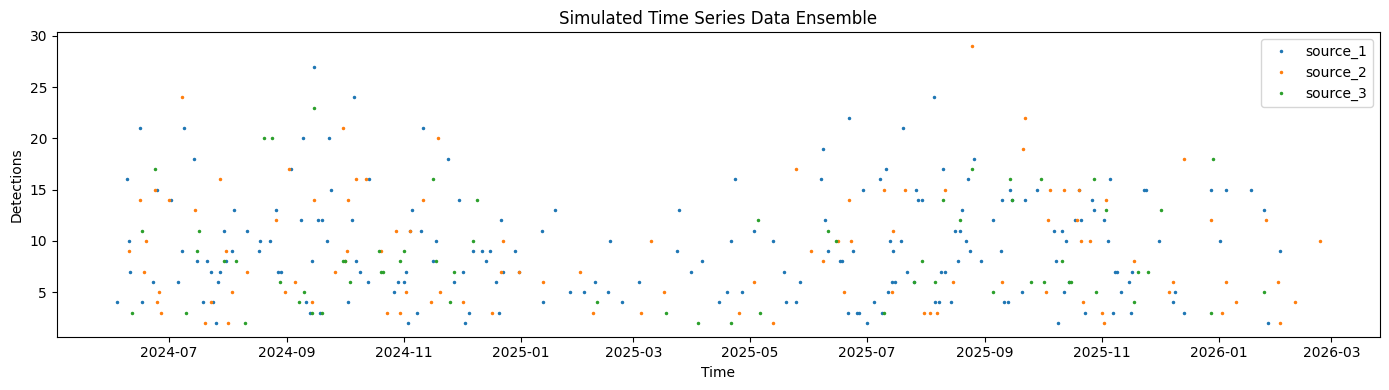

In [4]:
ts_raw = create_time_series_ensemble(
    start_date="2024-06-01",
    magnitude=15,    
    noise_scale=0.4, 
    floor=2,        # minimum 2 always present
    log_rates=[0.5, 0.3, 0.2],
    seasonal_cycles={1: 0.3, 7: 0.45, 365.25: 0.4},
    seed=int(time.time_ns()),
    y_label="source",
    plot=True,
)

In [5]:
source_cols = [col for col in ts_raw.columns if col != "time"]

ts_sparse = ts_raw.set_index("time")
ts_sparse.index = pd.DatetimeIndex(ts_sparse.index)
ts_sparse = validate_series(ts_sparse)

sparse_index = ts_sparse.index  # original uneven observation dates; used to filter anomalies back to real points

daily_index = pd.date_range(ts_sparse.index.min(), ts_sparse.index.max(), freq="D")

ts_daily = (
    ts_sparse
    .reindex(daily_index)
    .interpolate(method="time")
    .ffill()
    .bfill()
)
ts_daily.index.name = "time"
ts_daily = validate_series(ts_daily)

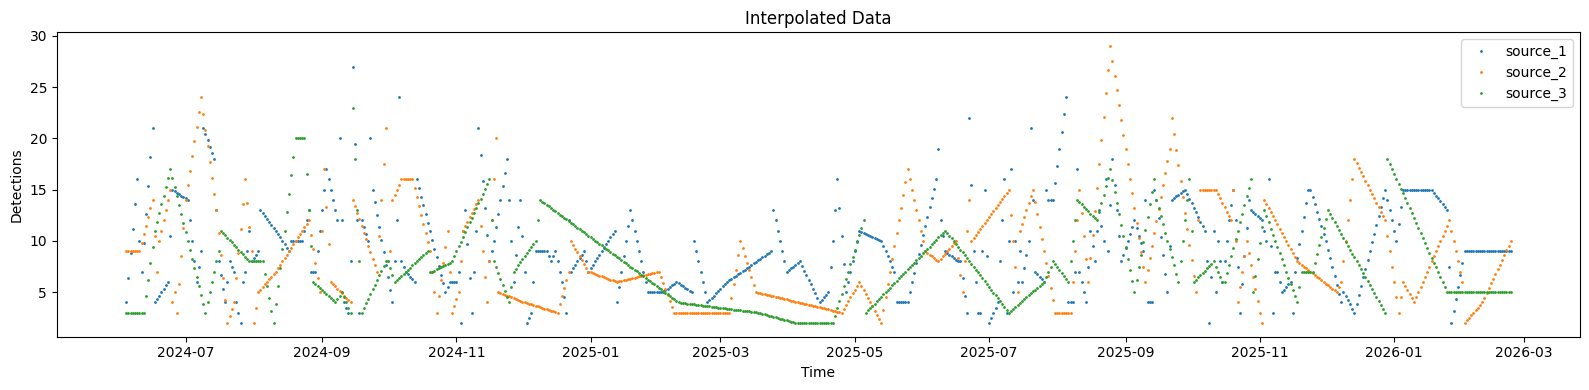

In [6]:
plt.figure(figsize=(16, 4))
for col in source_cols:
    plt.plot(ts_daily.index, ts_daily[col], ".", markersize=2, label=col)
plt.title("Interpolated Data")
plt.xlabel("Time")
plt.ylabel("Detections")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
seasonal_anomalies = filter_to_sparse(SeasonalAD(7).fit_detect(ts_daily), ts_sparse.index)
quantile_anomalies = QuantileAD(high=0.99, low=0.01).fit_detect(ts_sparse)
iqr_anomalies      = InterQuartileRangeAD(c=1.5).fit_detect(ts_sparse)
esd_anomalies      = filter_to_sparse(GeneralizedESDTestAD(alpha=0.3).fit_detect(ts_daily), ts_sparse.index)

2026-02-28 20:10:36,675 - adtk.detector._detector_1d - INFO - IQRAD initialized with lower_factor=None, upper_factor=3.0
2026-02-28 20:10:36,675 - adtk.detector._detector_1d - INFO - IQRAD fitting started: 630 non-null points
2026-02-28 20:10:36,677 - adtk.detector._detector_1d - INFO - Computed quartiles: Q1=1.3038, Q3=4.6956, IQR=3.3918
2026-02-28 20:10:36,677 - adtk.detector._detector_1d - INFO - IQRAD Thresholds set: abs_low_=-inf, abs_high_=14.8709
2026-02-28 20:10:36,680 - adtk.detector._detector_1d - INFO - IQRAD initialized with lower_factor=None, upper_factor=3.0
2026-02-28 20:10:36,681 - adtk.detector._detector_1d - INFO - IQRAD fitting started: 630 non-null points
2026-02-28 20:10:36,682 - adtk.detector._detector_1d - INFO - Computed quartiles: Q1=1.8555, Q3=5.3894, IQR=3.5339
2026-02-28 20:10:36,682 - adtk.detector._detector_1d - INFO - IQRAD Thresholds set: abs_low_=-inf, abs_high_=15.9911
2026-02-28 20:10:36,685 - adtk.detector._detector_1d - INFO - IQRAD initialized with

In [8]:
def plot_anomalies(
    anomaly_sets: list[AnomalySet],
    source_cols: list[str],
    ts_sparse: pd.DataFrame,
    ts_daily: pd.DataFrame,
    use_interpolated: bool = False,
):
    plot_data = ts_daily if use_interpolated else ts_sparse

    fig, axes = plt.subplots(len(anomaly_sets), 1, figsize=(15, 4 * len(anomaly_sets)))

    for ax, aset in zip(axes, anomaly_sets):
        for col in source_cols:
            ax.plot(plot_data.index, plot_data[col], linewidth=0.8, label=col)

        for date in aset.anomalies[aset.anomalies.any(axis=1)].index:
            flagged_cols = aset.anomalies.loc[date]
            flagged_cols = flagged_cols[flagged_cols.astype(bool)].index
            for col in flagged_cols:
                y = ts_sparse.loc[date, col] if date in ts_sparse.index else plot_data.loc[date, col]
                if pd.isna(y):
                    continue
                ax.scatter(date, y, color="red", s=40, zorder=5)

        ax.set_title(aset.title)
        ax.set_xlabel("Date")
        ax.set_ylabel("Detections")
        ax.legend()

    plt.tight_layout()
    plt.show()

In [9]:
def plot_ensemble_anomalies(
    ts_daily: pd.DataFrame,
    ts_sparse: pd.DataFrame,
    source_cols: list[str],
    vote_threshold_anomalies: pd.DataFrame,
    vote_iqr_anomalies: pd.DataFrame,
):
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    fig.suptitle("Ensemble Anomaly Detection", fontsize=12, fontweight="bold")
    plt.subplots_adjust(hspace=0.4)

    datasets = [
        ("Vote Threshold  (≥2 detectors)",    vote_threshold_anomalies),
        ("Vote IQR  (anomalous flag density)", vote_iqr_anomalies),
    ]

    for ax, (title, data) in zip(axes, datasets):
        for col in source_cols:
            ax.plot(ts_daily.index, ts_daily[col], linewidth=0.8, alpha=0.5)

        flagged = data.fillna(False).astype(bool)
        for col in [c for c in source_cols if c in flagged.columns]:
            for date in flagged.index[flagged[col]]:
                y = ts_sparse.loc[date, col] if date in ts_sparse.index else ts_daily.loc[date, col]
                if pd.isna(y):
                    continue
                ax.scatter(date, y, color="red", s=40, zorder=5, marker="o")

        n = int(flagged.values.sum())
        ax.set_title(f"{title}  ({n} flags)", fontsize=9, loc="left")
        ax.grid(True, linestyle="--", alpha=0.3)
        ax.set_ylabel("Detections")

    axes[-1].set_xlabel("Date")
    plt.tight_layout()
    plt.show()

In [10]:
def ensemble_anomalies(
    anomaly_sets: list[pd.DataFrame],
    min_votes: int = 2,
) -> pd.DataFrame:
    all_indices = anomaly_sets[0].index
    for df in anomaly_sets[1:]:
        all_indices = all_indices.union(df.index)

    all_columns = anomaly_sets[0].columns
    for df in anomaly_sets[1:]:
        all_columns = all_columns.union(df.columns)

    combined = sum(
        df.reindex(index=all_indices, columns=all_columns)
          .fillna(False)
          .astype(int)
        for df in anomaly_sets
    )
    return combined >= min_votes

In [11]:
from functools import reduce

def vote_score_series(
    anomaly_sets: list[pd.DataFrame],
    source_cols: list[str],
) -> pd.DataFrame:
    all_indices = reduce(lambda a, b: a.union(b), [df.index for df in anomaly_sets])

    scores = pd.DataFrame(0, index=all_indices, columns=source_cols)
    for df in anomaly_sets:
        aligned = df.reindex(index=all_indices, columns=source_cols).fillna(False).astype(int)
        scores = scores + aligned
    return scores

In [12]:
vote_threshold_anomalies = ensemble_anomalies(
    [seasonal_anomalies, quantile_anomalies, iqr_anomalies, esd_anomalies],
    min_votes=2
)

for name, df in [
    ("Seasonal",       seasonal_anomalies),
    ("Quantile",       quantile_anomalies),
    ("IQR",            iqr_anomalies),
    ("ESD",            esd_anomalies),
    ("Vote Threshold", vote_threshold_anomalies),
]:
    total = int(df.fillna(False).astype(int).sum().sum())
    print(f"{name:>16}: {total} flagged points")

        Seasonal: 5 flagged points
        Quantile: 3 flagged points
             IQR: 5 flagged points
             ESD: 7 flagged points
  Vote Threshold: 7 flagged points


In [13]:
vote_scores = vote_score_series(
    [seasonal_anomalies, quantile_anomalies, iqr_anomalies, esd_anomalies],
    source_cols=source_cols,
)
vote_iqr_anomalies = InterQuartileRangeAD(c=1.5).fit_detect(validate_series(vote_scores))

2026-02-28 20:10:36,803 - adtk.detector._detector_1d - INFO - IQRAD initialized with symmetric factor=1.50
2026-02-28 20:10:36,804 - adtk.detector._detector_1d - INFO - IQRAD fitting started: 285 non-null points
2026-02-28 20:10:36,805 - adtk.detector._detector_1d - INFO - Computed quartiles: Q1=0.0000, Q3=0.0000, IQR=0.0000
2026-02-28 20:10:36,805 - adtk.detector._detector_1d - INFO - IQRAD Thresholds set: abs_low_=0.0000, abs_high_=0.0000
2026-02-28 20:10:36,806 - adtk.detector._detector_1d - INFO - IQRAD initialized with symmetric factor=1.50
2026-02-28 20:10:36,806 - adtk.detector._detector_1d - INFO - IQRAD fitting started: 285 non-null points
2026-02-28 20:10:36,807 - adtk.detector._detector_1d - INFO - Computed quartiles: Q1=0.0000, Q3=0.0000, IQR=0.0000
2026-02-28 20:10:36,807 - adtk.detector._detector_1d - INFO - IQRAD Thresholds set: abs_low_=0.0000, abs_high_=0.0000
2026-02-28 20:10:36,808 - adtk.detector._detector_1d - INFO - IQRAD initialized with symmetric factor=1.50
202

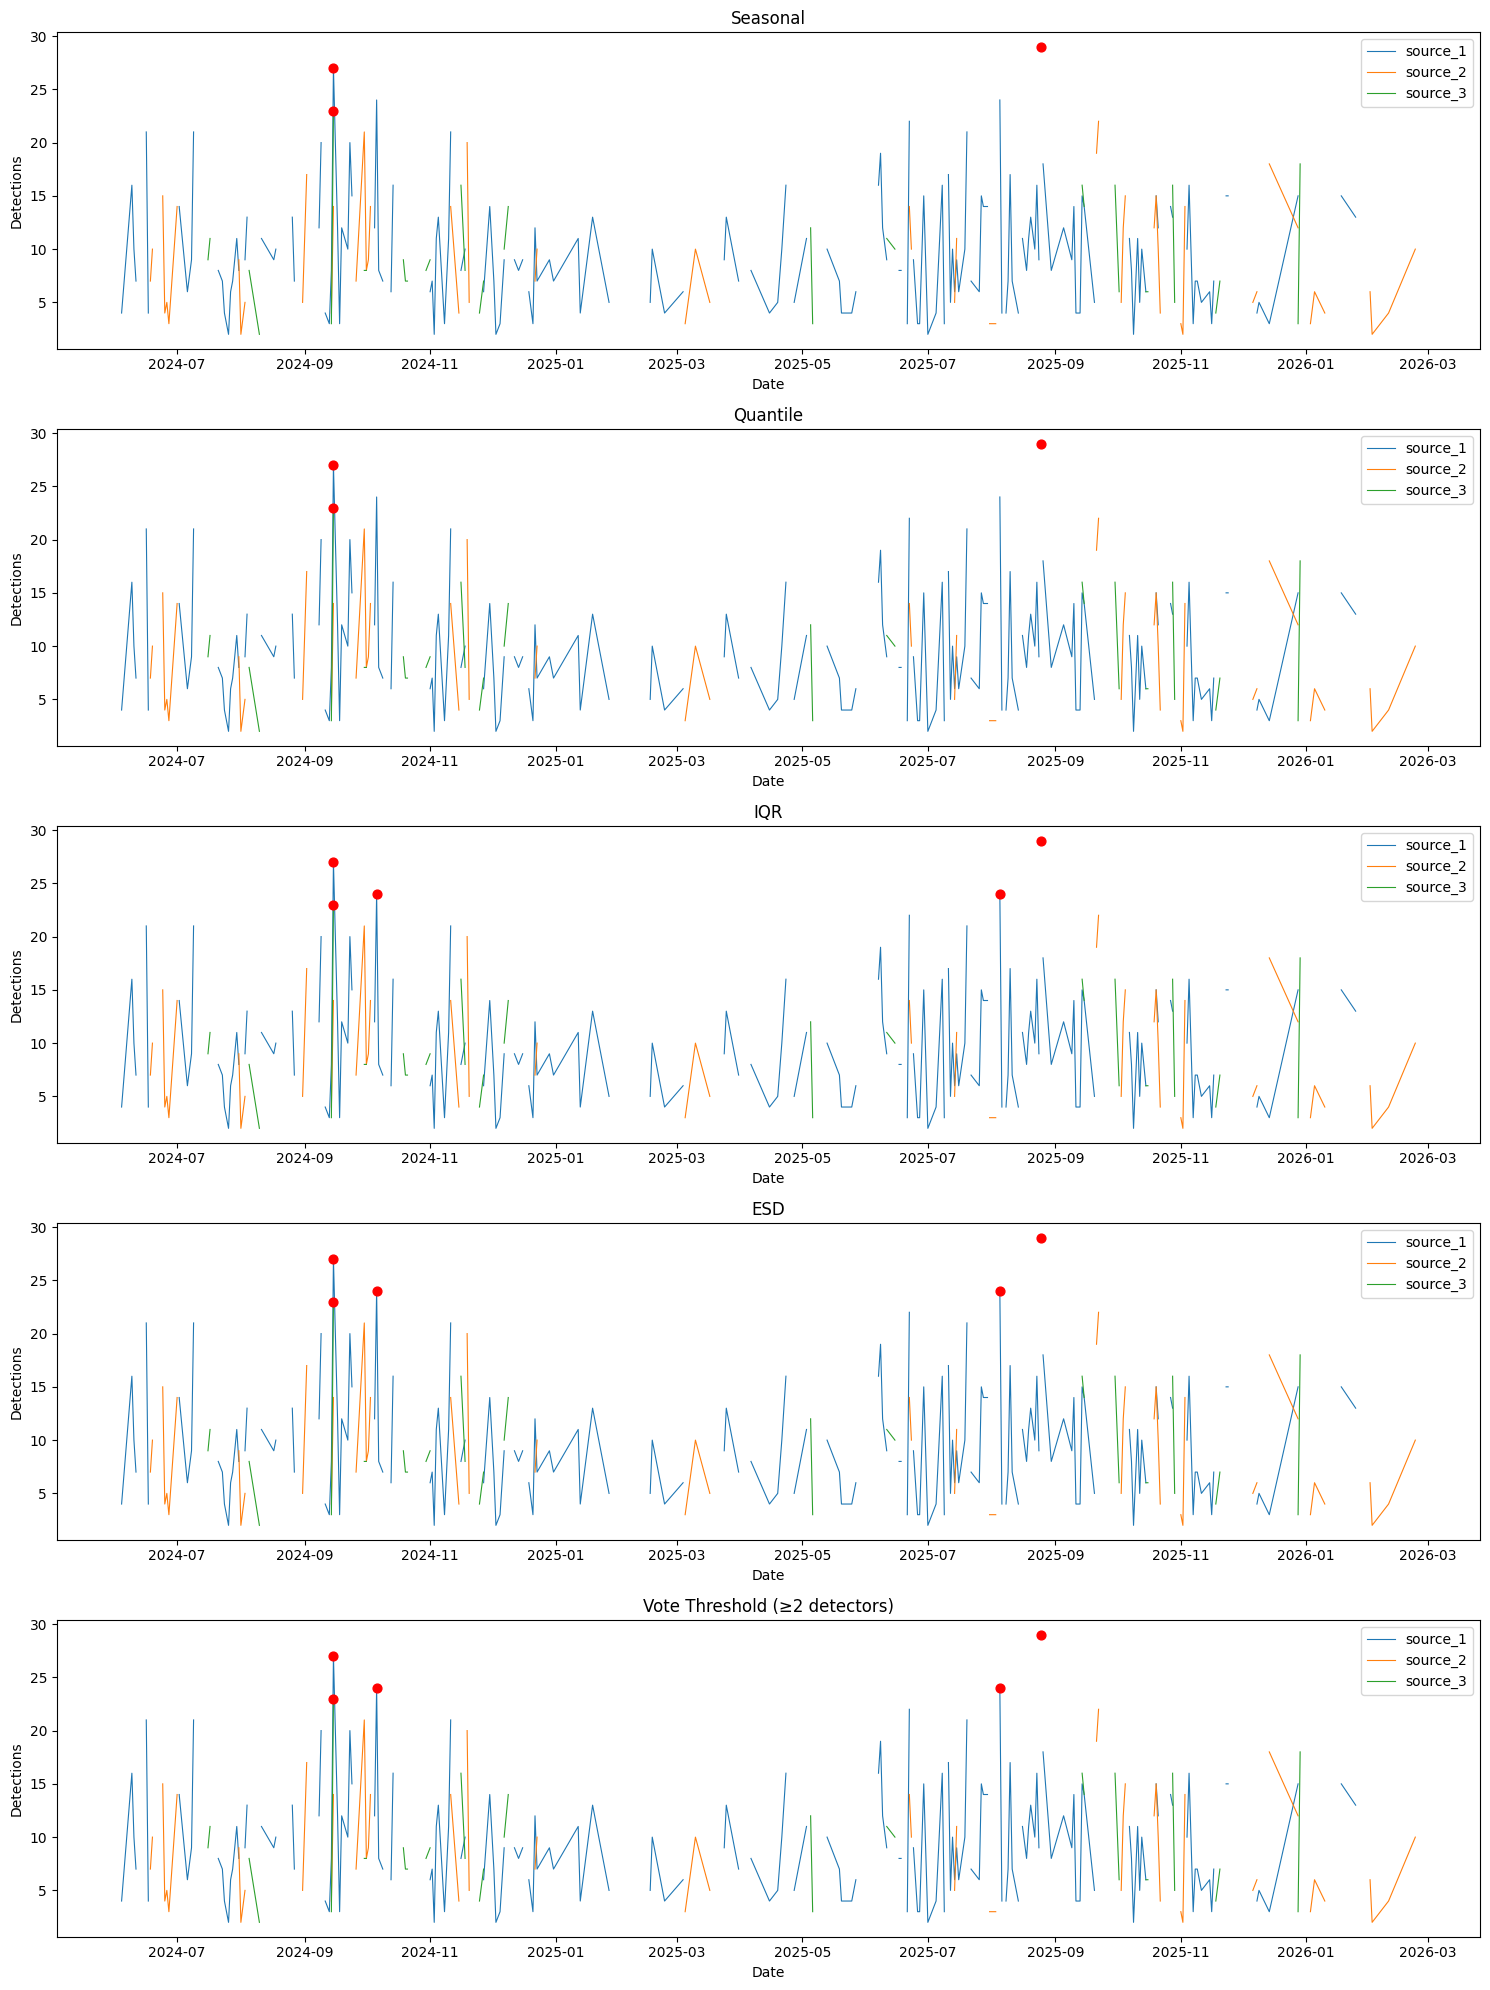

In [14]:
plot_anomalies(
    anomaly_sets=[
        AnomalySet(seasonal_anomalies,        "Seasonal"),
        AnomalySet(quantile_anomalies,        "Quantile"),
        AnomalySet(iqr_anomalies,             "IQR"),
        AnomalySet(esd_anomalies,             "ESD"),
        AnomalySet(vote_threshold_anomalies,  "Vote Threshold (≥2 detectors)"),
    ],
    source_cols=source_cols,
    ts_sparse=ts_sparse,
    ts_daily=ts_daily,
    use_interpolated=False,
)

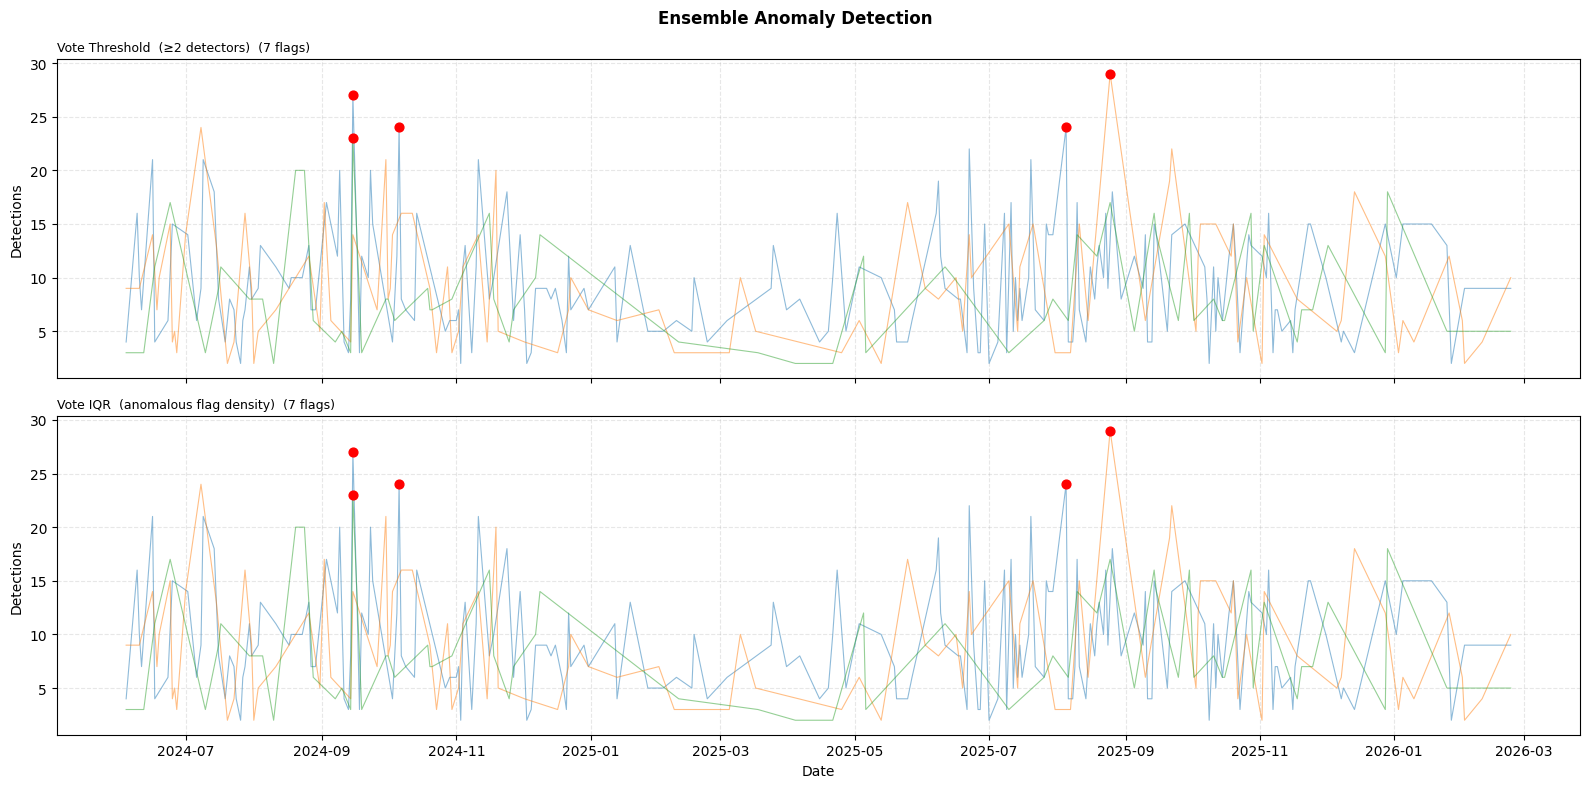

In [15]:
plot_ensemble_anomalies(
    ts_daily=ts_daily,
    ts_sparse=ts_sparse,
    source_cols=source_cols,
    vote_threshold_anomalies=vote_threshold_anomalies,
    vote_iqr_anomalies=vote_iqr_anomalies,
)